In [4]:
!pip install sentencepiece

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm

import math
import os
import re
import urllib.request
import zipfile
import numpy as np
import matplotlib.pyplot as plt

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        self.position = position

        self.pos_encoding = self._build_pos_encoding(position, d_model)

    def _get_angles(self, position, i, d_model):
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

        angle_rads = self._get_angles(pos, i, d_model)
        sines = torch.sin(angle_rads[:, 0::2])
        cosines = torch.cos(angle_rads[:, 1::2])

        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = sines
        pos_encoding[:, 1::2] = cosines

        pos_encoding = pos_encoding.unsqueeze(0)  # shape: [1, position, d_model]
        return pos_encoding

    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

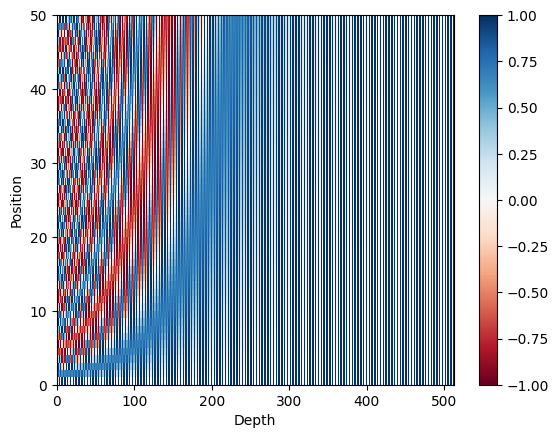

In [7]:
sample_pos_encoding = PositionalEncoding(50, 512)

plt.pcolormesh(sample_pos_encoding.pos_encoding.numpy()[0], cmap='RdBu')
plt.xlabel('Depth')
plt.xlim((0, 512))
plt.ylabel('Position')
plt.colorbar()
plt.show()

In [8]:
def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

In [9]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


In [10]:
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

In [11]:
x = torch.tensor([[1, 2, 0, 3, 0],
                  [0, 0, 0, 4, 5]])
mask = create_padding_mask(x)
print("입력 텐서 크기 :", x.shape)    # (2, 5)
print("생성된 마스크 크기 :", mask.shape)  # (2, 1, 1, 5)
print(mask)

입력 텐서 크기 : torch.Size([2, 5])
생성된 마스크 크기 : torch.Size([2, 1, 1, 5])
tensor([[[[0., 0., 1., 0., 1.]]],


        [[[1., 1., 1., 0., 0.]]]])


In [12]:
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

In [13]:
x = torch.tensor([[1, 2, 3, 4, 5]])
mask_1 = create_look_ahead_mask(x)
print("첫 번째 시퀀스:\n", mask_1, mask_1.shape)

첫 번째 시퀀스:
 tensor([[[[0., 1., 1., 1., 1.],
          [0., 0., 1., 1., 1.],
          [0., 0., 0., 1., 1.],
          [0., 0., 0., 0., 1.],
          [0., 0., 0., 0., 0.]]]]) torch.Size([1, 1, 5, 5])


In [14]:
x2 = torch.tensor([[0, 5, 1, 5, 5]])
mask_2 = create_look_ahead_mask(x2)
print("두 번째 시퀀스:\n", mask_2, mask_2.shape)

두 번째 시퀀스:
 tensor([[[[1., 1., 1., 1., 1.],
          [1., 0., 1., 1., 1.],
          [1., 0., 0., 1., 1.],
          [1., 0., 0., 0., 1.],
          [1., 0., 0., 0., 0.]]]]) torch.Size([1, 1, 5, 5])


In [15]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)  # 이전에 구현한 MHA
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 피드포워드 부분 (Dense -> ReLU -> Dense)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        # (1) 멀티 헤드 어텐션 (셀프 어텐션)
        attn_output = self.mha(x, x, x, mask)  # (batch_size, seq_len, d_model)
        attn_output = self.dropout1(attn_output)
        out1 = self.norm1(x + attn_output)     # 잔차 연결 + LayerNorm

        # (2) 피드포워드 신경망
        ffn_output = self.ffn(out1)            # (batch_size, seq_len, d_model)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.norm2(out1 + ffn_output)   # 잔차 연결 + LayerNorm

        return out2

In [16]:
class Encoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) EncoderLayer 쌓기
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        # (1) 임베딩 & sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 적용 + 드롭아웃
        x = self.pos_encoding(x)  # shape: (batch_size, seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓아올린 EncoderLayer 통과
        for layer in self.enc_layers:
            x = layer(x, mask)

        return x

In [17]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 서브 레이어 (인코더-디코더 어텐션)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # 2) 인코더-디코더 어텐션
        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        encdec_attn_out = self.dropout2(encdec_attn_out)
        out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out2 + ffn_out)  # 잔차 연결 + LayerNorm

        return out3

In [18]:
class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        # 실제 학습 시에는 최대 시퀀스 길이에 맞추어 쓰기도 함
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)

        return x

## 챗봇의 병렬 데이터 받아오기

In [19]:
# 코넬 대사 데이터셋 다운로드 URL
url = 'http://www.cs.cornell.edu/~cristian/data/cornell_movie_dialogs_corpus.zip'
zip_filename = '/content/cornell_movie_dialogs.zip'

# 이미 파일이 없는 경우에만 다운로드
if not os.path.exists(zip_filename):
    print(f"Downloading {zip_filename} ...")
    urllib.request.urlretrieve(url, zip_filename)
    print("Download complete.")

# ZIP 파일 압축 해제
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall()  # 현재 디렉토리에 풀림

# 코넬 대사 데이터 폴더 경로
path_to_dataset = os.path.join("/content/cornell movie-dialogs corpus")

# 개별 파일 경로 설정
path_to_movie_lines = os.path.join(path_to_dataset, 'movie_lines.txt')
path_to_movie_conversations = os.path.join(path_to_dataset, 'movie_conversations.txt')

print("path_to_dataset:", path_to_dataset)
print("path_to_movie_lines:", path_to_movie_lines)
print("path_to_movie_conversations:", path_to_movie_conversations)

Download complete.
path_to_dataset: /content/cornell movie-dialogs corpus
path_to_movie_lines: /content/cornell movie-dialogs corpus/movie_lines.txt
path_to_movie_conversations: /content/cornell movie-dialogs corpus/movie_conversations.txt


In [20]:
# 사용할 샘플의 최대 개수
MAX_SAMPLES = 50000
print(MAX_SAMPLES)

50000


In [21]:
# 전처리 함수
def preprocess_sentence(sentence):
  # 입력받은 sentence를 소문자로 변경하고 양쪽 공백을 제거
  sentence = sentence.lower().strip()

  # 단어와 구두점(punctuation) 사이의 거리를 만듭니다.
  # 예를 들어서 "I am a student." => "I am a student ."와 같이
  # student와 온점 사이에 거리를 만듭니다.
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
  sentence = re.sub(r'[" "]+', " ", sentence)

  # (a-z, A-Z, ".", "?", "!", ",")를 제외한 모든 문자를 공백인 ' '로 대체합니다.
  sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
  sentence = sentence.strip()
  return sentence
print("슝=3")

슝=3


In [22]:
sample_sentence = "안녕하세요? Hello! I'm a student😊, nice to meet you!"

preprocessed_sentence = preprocess_sentence(sample_sentence)
print(preprocessed_sentence)

? hello ! i m a student , nice to meet you !


In [23]:
def read_cornell_data(path_to_movie_lines, path_to_movie_conversations, max_samples=50000):
    id2line = {}
    with open(path_to_movie_lines, 'r', errors='ignore') as f:
        lines = f.readlines()
    for line in lines:
        parts = line.strip().split(" +++$+++ ")
        if len(parts) >= 5:
            line_id = parts[0]
            text = parts[4]
            id2line[line_id] = text

    pairs = []
    with open(path_to_movie_conversations, 'r', errors='ignore') as f:
        conv_lines = f.readlines()
    for line in conv_lines:
        parts = line.strip().split(" +++$+++ ")
        if len(parts) < 4:
            continue
        # 대화 ID 목록 추출: ["L1045","L1044","L1043", ...]
        conv_str = parts[3]
        conv_list = conv_str[1:-1].split(", ")
        conv_list = [c.strip("'") for c in conv_list]  # "'L1045'" -> "L1045"

        # 연속된 두 문장씩 (질문, 답변) 구성
        for i in range(len(conv_list) - 1):
            q_id = conv_list[i]
            a_id = conv_list[i+1]
            q_text = id2line.get(q_id, "")
            a_text = id2line.get(a_id, "")
            # 간단 전처리(소문자 변환 정도만 예시)
            q_text = preprocess_sentence(q_text)
            a_text = preprocess_sentence(a_text)

            pairs.append((q_text, a_text))
            if len(pairs) >= max_samples:
                return pairs
    return pairs

In [24]:
pairs = read_cornell_data(path_to_movie_lines, path_to_movie_conversations, max_samples=MAX_SAMPLES)

print('전체 샘플 수 :', len(pairs))

전체 샘플 수 : 50000


In [25]:
corpus_file = "clean_corpus.txt"
with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a in pairs:
        f.write(q + "\n")
        f.write(a + "\n")

In [26]:
spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix="spm_cornell",
    vocab_size=8000,
    character_coverage=1.0,
    model_type="bpe",
    max_sentence_length=999999,
    bos_id=1,  # <s> (Beginning of Sentence) 설정
    eos_id=2,  # </s> (End of Sentence) 설정
    pad_id=0,  # Padding ID 설정
    unk_id=3   # Unknown Token ID 설정
)

In [27]:
sp = spm.SentencePieceProcessor()
sp.Load("spm_cornell.model")

True

In [28]:
# 예제 문장
sentence = "I'm learning PyTorch with SentencePiece!"

sentence = preprocess_sentence(sentence)
print("전처리 후의 문장:", sentence)

# 1. 토크나이징 (subword 단위로 분할)
tokens = sp.encode(sentence, out_type=str)
print("Tokenized:", tokens)

# 2. 인코딩 (서브워드를 정수 ID로 변환)
encoded = sp.encode(sentence, out_type=int)
print("Encoded:", encoded)

# 3. 디코딩 (정수 ID → 원본 문장 복원)
decoded = sp.decode(encoded)
print("Decoded:", decoded)


전처리 후의 문장: i m learning pytorch with sentencepiece !
Tokenized: ['▁i', '▁m', '▁learning', '▁p', 'y', 't', 'or', 'ch', '▁with', '▁sent', 'ence', 'p', 'iece', '▁!']
Encoded: [6, 13, 4954, 37, 7983, 7971, 36, 119, 113, 1412, 651, 7991, 4122, 69]
Decoded: i m learning pytorch with sentencepiece !


In [29]:
class CornellDataset(Dataset):
    def __init__(self, pairs, sp, max_length=40):
        super().__init__()
        self.sp = sp
        self.max_length = max_length
        self.data = []

        for q_text, a_text in pairs:
            # 1) 토크나이즈
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)

            # 2) [CLS]/[SEP] 같은 별도 스페셜 토큰을 쓸 수도 있으나,
            #    여기서는 SentencePiece 기본 <s>, </s> 등 혹은 사용자 정의 토큰 활용 가능
            #    간단히 <s>=sp.bos_id(), </s>=sp.eos_id()로 가정해본다면:
            #    sp.SetEncodeExtraOptions("bos:eos") 등으로 설정하는 방법도 있음.
            # 여기서는 수동으로 bos/eos id를 붙인다고 가정
            bos_id = sp.bos_id() if sp.bos_id() >= 0 else 1  # 혹은 임의값
            eos_id = sp.eos_id() if sp.eos_id() >= 0 else 2

            q_tokens = [bos_id] + q_ids + [eos_id]
            a_tokens = [bos_id] + a_ids + [eos_id]

            # 3) 길이 제한
            if len(q_tokens) > max_length or len(a_tokens) > max_length:
                continue

            # 4) 고정 길이 패딩
            q_tokens += [0]*(max_length - len(q_tokens))  # 0 -> <pad> 가정
            a_tokens += [0]*(max_length - len(a_tokens))

            # 5) 디코더 입력(dec_input): a_tokens[:-1], 타겟(outputs): a_tokens[1:]
            #    (teacher forcing용)
            dec_input = a_tokens[:-1]
            target = a_tokens[1:]

            self.data.append({
                "enc_input": q_tokens,
                "dec_input": dec_input,
                "target": target
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        enc_input = torch.tensor(sample["enc_input"], dtype=torch.long)
        dec_input = torch.tensor(sample["dec_input"], dtype=torch.long)
        target = torch.tensor(sample["target"], dtype=torch.long)
        return enc_input, dec_input, target

In [30]:
dataset = CornellDataset(pairs, sp, max_length=40)

In [31]:
for encoder_input, decoder_input, decoder_label  in dataset:
    print("텐서 크기 :",encoder_input.size())
    print(encoder_input)
    print(sp.decode(encoder_input.tolist()))
    print(decoder_input)
    print(sp.decode(decoder_input.tolist()))
    print(decoder_label)
    print(sp.decode(decoder_label.tolist()))
    break

텐서 크기 : torch.Size([40])
tensor([   1,  115,   52,  321,   99, 1609,   23,  304, 7997, 7734,   62,   36,
        7978,  271,   61,   61,  891, 6222,  121, 1060,   39, 3631, 7741, 1337,
          15,  141,  280, 1882,  919,  161,   72,   19,  333,  103,    5,  463,
           5,    2,    0,    0])
can we make this quick ? roxanne korrine and andrew barrett are having an incredibly horrendous public break up on the quad . again .
tensor([   1,  189,   17,    6,  450,   52,   20,  539,  113,  523,   21,  182,
        5984,   17,  156,   57,   10,  358,  113,   14,    5,    2,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0])
well , i thought we d start with pronunciation , if that s okay with you .
tensor([ 189,   17,    6,  450,   52,   20,  539,  113,  523,   21,  182, 5984,
          17,  156,   57,   10,  358,  113,   14,    5,    2,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0

In [32]:
dataloader = DataLoader(dataset,batch_size=32,shuffle=True)

In [33]:
for encoder_input, decoder_input, decoder_label in dataloader:
    print(encoder_input.size())
    print(decoder_input.size())
    print(decoder_label.size())
    break

torch.Size([32, 40])
torch.Size([32, 39])
torch.Size([32, 39])


## 모델 정의 및 학습하기

In [34]:
class Transformer(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,      # 인코더/디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 dropout=0.1):
        super(Transformer, self).__init__()

        # 인코더
        self.encoder = Encoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 디코더
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 최종 출력층: (d_model) -> (vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size)

        # 참고: 텐서플로우 코드의 `name="transformer"`는 파이토치에선 보통 사용 안 함

    def forward(self, inputs, dec_inputs):
        # 1) 인코더 패딩 마스크 생성
        enc_padding_mask = create_padding_mask(inputs)     # shape (batch_size, 1, 1, src_seq_len)

        # 2) 디코더 look-ahead + 패딩 마스크
        look_ahead_mask = create_look_ahead_mask(dec_inputs)  # shape (batch_size, 1, tgt_seq_len, tgt_seq_len)

        # 3) 디코더에서 인코더 출력 쪽을 마스킹할 때 쓸 패딩 마스크
        dec_padding_mask = create_padding_mask(inputs)        # shape (batch_size, 1, 1, src_seq_len)

        # 4) 인코더 수행
        enc_outputs = self.encoder(
            x=inputs,
            mask=enc_padding_mask
        )  # shape: (batch_size, src_seq_len, d_model)

        # 5) 디코더 수행
        dec_outputs = self.decoder(
            x=dec_inputs,           # (batch_size, tgt_seq_len)
            enc_outputs=enc_outputs,# (batch_size, src_seq_len, d_model)
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask
        )  # shape: (batch_size, tgt_seq_len, d_model)

        # 6) 최종 Dense (vocab_size)
        logits = self.final_linear(dec_outputs)  # (batch_size, tgt_seq_len, vocab_size)
        return logits

### 모델 생성

In [35]:
# 예: 하이퍼파라미터 설정
NUM_LAYERS = 2     # 인코더/디코더 층 수
D_MODEL = 256      # 임베딩 및 내부 표현 차원
NUM_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
UNITS = 512        # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.1      # 드롭아웃 비율
VOCAB_SIZE = 8000 # 단어 집합 크기(예시)

# 모델 생성
model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

print(model)

Transformer(
  (encoder): Encoder(
    (embedding): Embedding(8000, 256)
    (pos_encoding): PositionalEncoding()
    (dropout): Dropout(p=0.1, inplace=False)
    (enc_layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (mha): MultiHeadAttention(
          (query_dense): Linear(in_features=256, out_features=256, bias=True)
          (key_dense): Linear(in_features=256, out_features=256, bias=True)
          (value_dense): Linear(in_features=256, out_features=256, bias=True)
          (out_dense): Linear(in_features=256, out_features=256, bias=True)
        )
        (dropout1): Dropout(p=0.1, inplace=False)
        (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=256, bias=True)
        )
        (dropout2): Dropout(p=0.1, inplace=False)
        (norm2): LayerNorm((256,), eps=1e-06, elementwise_aff

### 손실 함수(Loss Function)

In [36]:
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

### 커스텀 된 학습률(Learning rate)

In [37]:
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

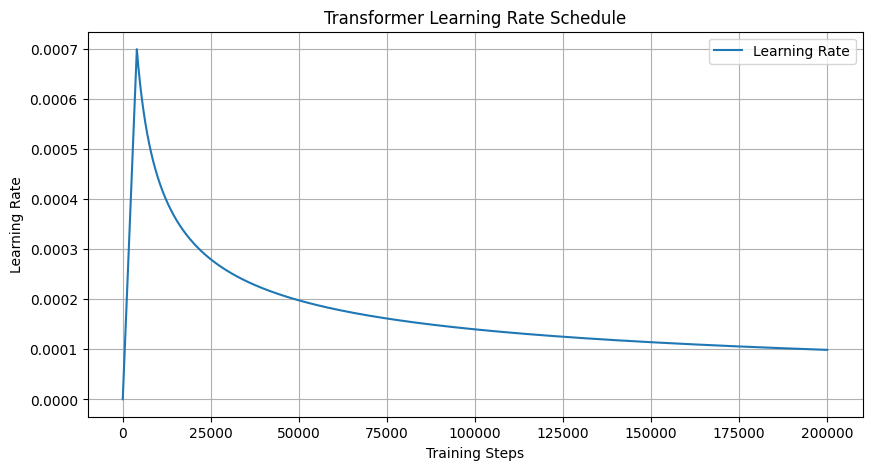

In [38]:
# 하이퍼파라미터 설정
d_model = 512
warmup_steps = 4000
total_steps = 200000  # 총 학습 스텝

# 학습률 스케줄 시각화
steps = np.arange(1, total_steps + 1)
learning_rates = [get_lr_lambda(d_model, warmup_steps)(step) for step in steps]

# 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(steps, learning_rates, label="Learning Rate")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("Transformer Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()

### 모델 컴파일

In [39]:
# Optimizer 정의
optimizer = optim.Adam(model.parameters(), betas=(0.9, 0.98), eps=1e-9)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=4000))

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc

In [40]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

### 훈련하기

In [41]:
def train_step(model, batch, optimizer, loss_function, device):
    model.train()
    enc_input, dec_input, target = [x.to(device) for x in batch]

    optimizer.zero_grad()

    # 모델 포워드 패스
    logits = model(enc_input, dec_input)  # (batch_size, seq_len, vocab_size)

    # Loss 계산 (패딩 토큰 무시)
    loss = loss_function(logits.permute(0, 2, 1), target)  # (batch_size, vocab_size, seq_len) 필요

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss.item(), accuracy_function(logits, target, pad_id=sp.pad_id())

In [42]:
def train(model, dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)

    for epoch in range(num_epochs):
        total_loss, total_acc = 0, 0
        for step, batch in enumerate(dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc

            # 일정 스텝마다 로그 출력
            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}")

            # 학습률 스케줄러 업데이트
            scheduler.step()

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)
        print(f"Epoch {epoch+1} Completed - Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")

In [43]:
%%time

train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=25,  # 원하는 에폭 수
    device=device
)

[Epoch 1, Step 0] Loss: 9.1214, Acc: 0.0000
[Epoch 1, Step 100] Loss: 9.1196, Acc: 0.0000
[Epoch 1, Step 200] Loss: 9.0862, Acc: 0.0000
[Epoch 1, Step 300] Loss: 9.1044, Acc: 0.0000
[Epoch 1, Step 400] Loss: 9.0805, Acc: 0.0000
[Epoch 1, Step 500] Loss: 9.0733, Acc: 0.0000
[Epoch 1, Step 600] Loss: 9.0757, Acc: 0.0000
[Epoch 1, Step 700] Loss: 9.0854, Acc: 0.0000
[Epoch 1, Step 800] Loss: 8.9902, Acc: 0.0000
[Epoch 1, Step 900] Loss: 9.0675, Acc: 0.0000
[Epoch 1, Step 1000] Loss: 9.0192, Acc: 0.0000
[Epoch 1, Step 1100] Loss: 8.9684, Acc: 0.0000
[Epoch 1, Step 1200] Loss: 8.9496, Acc: 0.0023
[Epoch 1, Step 1300] Loss: 8.9002, Acc: 0.0000
Epoch 1 Completed - Avg Loss: 9.0475, Avg Acc: 0.0004
[Epoch 2, Step 0] Loss: 8.9032, Acc: 0.0000
[Epoch 2, Step 100] Loss: 8.8540, Acc: 0.0079
[Epoch 2, Step 200] Loss: 8.8912, Acc: 0.0199
[Epoch 2, Step 300] Loss: 8.9078, Acc: 0.0071
[Epoch 2, Step 400] Loss: 8.8205, Acc: 0.0230
[Epoch 2, Step 500] Loss: 8.8147, Acc: 0.0387
[Epoch 2, Step 600] Loss: 

## 챗봇 테스트하기

In [44]:
def decoder_inference(model, sentence, tokenizer, device='cpu'):
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    MAX_LENGTH = 40


    # 전처리
    sentence = preprocess_sentence(sentence)

    # 인코더 입력: [START] + 인코딩 + [END]
    enc_input_ids = [START_TOKEN] + tokenizer.encode(sentence) + [END_TOKEN]
    # 차원 확장: (batch_size=1, seq_len)
    enc_input = torch.tensor([enc_input_ids], dtype=torch.long, device=device)

    # 디코더 입력(dec_input)을 START_TOKEN만 포함한 상태로 시작
    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)

    model.eval()  # 모델 평가 모드
    with torch.no_grad():
        for i in range(MAX_LENGTH):
            # 모델 forward: (enc_input, dec_input) -> (batch_size=1, seq_len, vocab_size)
            logits = model(enc_input, dec_input)

            # 마지막 타임스텝의 예측만 추출: shape (1, 1, vocab_size)
            # logits[:, -1, :] -> (1, vocab_size)
            last_step_logits = logits[:, -1, :]

            # argmax로 가장 높은 확률의 토큰 선택
            predicted_id = torch.argmax(last_step_logits, dim=-1)  # shape: (1,)

            # 종료 토큰이면 중단
            if predicted_id.item() == END_TOKEN:
                break

            # 디코더 입력(dec_input)에 예측 토큰을 이어붙임
            predicted_id = predicted_id.unsqueeze(0)  # shape (1,1)
            dec_input = torch.cat([dec_input, predicted_id], dim=1)

    # 최종 시퀀스: dec_input: (1, seq_len)에서 (seq_len,)로
    output_sequence = dec_input.squeeze(0).tolist()  # e.g. [START_TOKEN, ..., 토큰들...]

    return output_sequence

In [45]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    # 디코더 인퍼런스 -> 예측된 토큰 시퀀스
    output_seq = decoder_inference(model, sentence, tokenizer, device=device)

    # 토크나이저로 디코딩 (패딩, START/END 토큰 등은 제외하거나 처리)
    # 여기서는 단순히 tokenizer.decode() 직접 호출
    predicted_sentence = tokenizer.decode(
        [token for token in output_seq if token < tokenizer.GetPieceSize()]
    )

    print("입력 :", sentence)
    print("출력 :", predicted_sentence)
    return predicted_sentence

In [46]:
sentence = 'Where have you been?'
sentence_generation(model, sentence, sp, device)

입력 : Where have you been?
출력 : i .


'i .'

In [47]:
sentence = "It's a trap"
sentence_generation(model, sentence, sp, device)

입력 : It's a trap
출력 : i .


'i .'

# 트랜스포머로 만드는 대화형 챗봇 [프로젝트]

## 1. 한국어 데이터로 챗봇 만들기

In [48]:
import torch
print(torch.__version__)

2.9.0+cu126


## Step 1. 데이터 수집하기

In [49]:
!wget https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv

--2026-02-06 05:46:11--  https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv [following]
--2026-02-06 05:46:12--  https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 889842 (869K) [text/plain]
Saving to: ‘ChatbotData.csv’

ChatbotData.csv     100%[===================>] 868.99K  --.-KB/s    in 0.005s  

2026-02-06 05:46:12 (155 MB/s) - ‘ChatbotData.csv’ saved [889842/889842]



##Step 2. 데이터 전처리하기

In [57]:
import pandas as pd
import re

# 1. CSV 데이터 로드
train_data = pd.read_csv('ChatbotData.csv')

print("데이터 개수:", len(train_data))
train_data.head()

# 2. 한글 전처리 함수 정의
def preprocess_sentence(sentence):
    """
    문장을 전처리하는 함수입니다.
    1. 소문자 변환 (영어의 경우)
    2. 구두점(.,!?) 주변에 공백 추가
    3. 한글, 영문, 숫자, 주요 구두점을 제외한 특수문자 제거
    """
    # 입력받은 sentence를 소문자로 변경하고 양쪽 공백을 제거
    sentence = sentence.lower().strip()

    # 단어와 구두점(punctuation) 사이에 띄어쓰기 해주기
    # "12시 땡!" -> "12시 땡 !"
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)

    # [수정한 부분]
    # 이전 영어 챗봇: [^a-zA-Z...] -> 영어만 남김
    # 한국어 챗봇: [^ㄱ-ㅎ가-힣a-zA-Z0-9...] -> 한글(자음,모음,완성형), 영어, 숫자, 구두점만 남김
    sentence = re.sub(r"[^ㄱ-ㅎ가-힣a-zA-Z0-9?.!,]+", " ", sentence)

    sentence = sentence.strip()
    return sentence

# 3. 전처리 함수 테스트
# 질문(Q)과 답변(A)에 모두 적용
print("전처리 전:", train_data['Q'][0])
print("전처리 후:", preprocess_sentence(train_data['Q'][0]))
print("-" * 30)
print("전처리 전:", train_data['Q'][100])
print("전처리 후:", preprocess_sentence(train_data['Q'][100]))

# 4. 전체 데이터 전처리 및 리스트 생성
questions = []
answers = []

for sentence in train_data['Q']:
    questions.append(preprocess_sentence(sentence))

for sentence in train_data['A']:
    answers.append(preprocess_sentence(sentence))

print("-" * 30)
print(f"전처리 후 질문 개수: {len(questions)}, 전처리 후 답변 개수: {len(answers)}")

데이터 개수: 11823
전처리 전: 12시 땡!
전처리 후: 12시 땡 !
------------------------------
전처리 전: 거지됐어
전처리 후: 거지됐어
------------------------------
전처리 후 질문 개수: 11823, 전처리 후 답변 개수: 11823


##Step 3. SentencePiece 사용하기

In [60]:
import sentencepiece as spm
import os

# 1. 전처리된 데이터로 Corpus 생성
# SentencePiece 학습을 위해 질문과 답변을 모두 한 파일로!
corpus_file = 'korean_corpus.txt'

with open(corpus_file, 'w', encoding='utf-8') as f:
    for sentence in questions + answers:
        f.write(sentence + '\n')

# 2. SentencePiece 모델 학습
# vocab_size: 단어 집합의 크기
# model_type: 'bpe' (Byte Pair Encoding)
spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix='korean_spm',  # 저장될 모델 파일 이름 (korean_spm.model)
    vocab_size=8000,            # 단어 집합 크기
    model_type='bpe',
    max_sentence_length=9999,
    pad_id=0,                   # [PAD] 토큰 ID
    bos_id=1,                   # [BOS] 시작 토큰 ID
    eos_id=2,                   # [EOS] 종료 토큰 ID
    unk_id=3,                   # [UNK] 미등록 토큰 ID
    character_coverage=1.0,     # 문자의 100%를 커버 (한글은 1.0 권장) = 데이터에 등장하는 모든 글자(가나다, ABC, !? 등)를 단어장에 등록
)

# 3. 학습된 모델 로드 및 테스트
vocab = spm.SentencePieceProcessor()
vocab.Load('korean_spm.model')

# 테스트
test_sentence = "안녕하세요? 만나서 정말 반갑습니다."
test_sentence = preprocess_sentence(test_sentence) # 전처리 먼저 적용

# 인코딩: 문장 -> 정수 시퀀스
encoded = vocab.encode_as_ids(test_sentence)
# 토큰화 결과: 문장 -> subword 리스트
tokens = vocab.encode_as_pieces(test_sentence)
# 디코딩: 정수 시퀀스 -> 문장
decoded = vocab.decode_ids(encoded)

print("-" * 30)
print(f"원본 문장: {test_sentence}")
print(f"토큰화 (Subwords): {tokens}")
print(f"정수 인코딩(IDs): {encoded}")
print(f"디코딩: {decoded}")

SentencePiece 모델 학습 완료
------------------------------
원본 문장: 안녕하세요 ? 만나서 정말 반갑습니다 .
토큰화 (Subwords): ['▁안녕하세요', '▁?', '▁만나서', '▁정말', '▁반갑', '습니다', '▁.']
정수 인코딩(IDs): [4617, 11, 1926, 216, 4841, 151, 4]
디코딩: 안녕하세요 ? 만나서 정말 반갑습니다 .


## Step 4. 모델 구성하기

### 4.1 기본 설정 및 유틸리티 함수 구현

In [61]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
import time
from torch.utils.data import Dataset, DataLoader

# 1. GPU 사용 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. 포지셔널 인코딩 (Positional Encoding)
def get_angles(pos, i, d_model):
    angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
    return pos * angle_rates

def positional_encoding(position, d_model):
    angle_rads = get_angles(np.arange(position)[:, np.newaxis],
                            np.arange(d_model)[np.newaxis, :],
                            d_model)
    # 짝수: sin, 홀수: cos
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    pos_encoding = angle_rads[np.newaxis, ...]
    return torch.tensor(pos_encoding, dtype=torch.float32).to(device)

# 3. 마스킹 함수 (Padding Mask & Look-ahead Mask)
def create_padding_mask(seq):
    # 시퀀스에서 0(패딩)인 부분을 찾아 마스킹 (Batch, 1, 1, Seq_len)
    seq = torch.eq(seq, 0).float()
    return seq[:, np.newaxis, np.newaxis, :].to(device)

def create_look_ahead_mask(size):
    # 앞에 나올 토큰을 보지 못하도록 마스킹 (상삼각 행렬)
    mask = torch.triu(torch.ones(size, size), diagonal=1)
    return mask.to(device)

###4.2 어텐션(Attention) 및 레이어 구현

In [62]:
# 1. Scaled Dot Product Attention
def scaled_dot_product_attention(q, k, v, mask):
    matmul_qk = torch.matmul(q, k.transpose(-2, -1))
    dk = torch.tensor(k.shape[-1], dtype=torch.float32)
    scaled_attention_logits = matmul_qk / torch.sqrt(dk)

    if mask is not None:
        scaled_attention_logits += (mask * -1e9)  # 마스킹 된 곳은 아주 작은 값으로

    attention_weights = F.softmax(scaled_attention_logits, dim=-1)
    output = torch.matmul(attention_weights, v)
    return output, attention_weights

# 2. MultiHead Attention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % self.num_heads == 0
        self.depth = d_model // self.num_heads

        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)
        self.dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def forward(self, v, k, q, mask):
        batch_size = q.size(0)
        q = self.split_heads(self.wq(q), batch_size)
        k = self.split_heads(self.wk(k), batch_size)
        v = self.split_heads(self.wv(v), batch_size)

        scaled_attention, _ = scaled_dot_product_attention(q, k, v, mask)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()
        original_size_attention = scaled_attention.view(batch_size, -1, self.d_model)
        output = self.dense(original_size_attention)
        return output

# 3. Feed Forward Network
def point_wise_feed_forward_network(d_model, dff):
    return nn.Sequential(
        nn.Linear(d_model, dff),
        nn.ReLU(),
        nn.Linear(dff, d_model)
    )

# 4. Encoder Layer
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = point_wise_feed_forward_network(d_model, dff)
        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(rate)
        self.dropout2 = nn.Dropout(rate)

    def forward(self, x, mask):
        attn_output = self.mha(x, x, x, mask)
        attn_output = self.dropout1(attn_output)
        out1 = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.layernorm2(out1 + ffn_output)
        return out2

# 5. Decoder Layer
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(DecoderLayer, self).__init__()
        self.mha1 = MultiHeadAttention(d_model, num_heads)
        self.mha2 = MultiHeadAttention(d_model, num_heads)
        self.ffn = point_wise_feed_forward_network(d_model, dff)

        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)
        self.layernorm3 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(rate)
        self.dropout2 = nn.Dropout(rate)
        self.dropout3 = nn.Dropout(rate)

    def forward(self, x, enc_output, look_ahead_mask, padding_mask):
        # 1. Self Attention
        attn1 = self.mha1(x, x, x, look_ahead_mask)
        attn1 = self.dropout1(attn1)
        out1 = self.layernorm1(x + attn1)

        # 2. Encoder-Decoder Attention
        attn2 = self.mha2(enc_output, enc_output, out1, padding_mask)
        attn2 = self.dropout2(attn2)
        out2 = self.layernorm2(out1 + attn2)

        # 3. FFN
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output)
        out3 = self.layernorm3(out2 + ffn_output)
        return out3

###4.3 트랜스포머(Transformer) 모델

In [63]:
class Encoder(nn.Module):
    def __init__(self, num_layers, d_model, num_heads, dff, vocab_size, maximum_position_encoding, rate=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)
        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, dff, rate) for _ in range(num_layers)])
        self.dropout = nn.Dropout(rate)

    def forward(self, x, mask):
        seq_len = x.shape[1]
        x = self.embedding(x)
        x *= torch.sqrt(torch.tensor(self.d_model, dtype=torch.float32))
        x += self.pos_encoding[:, :seq_len, :]
        x = self.dropout(x)
        for i in range(self.num_layers):
            x = self.enc_layers[i](x, mask)
        return x

class Decoder(nn.Module):
    def __init__(self, num_layers, d_model, num_heads, dff, vocab_size, maximum_position_encoding, rate=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)
        self.dec_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, dff, rate) for _ in range(num_layers)])
        self.dropout = nn.Dropout(rate)

    def forward(self, x, enc_output, look_ahead_mask, padding_mask):
        seq_len = x.shape[1]
        x = self.embedding(x)
        x *= torch.sqrt(torch.tensor(self.d_model, dtype=torch.float32))
        x += self.pos_encoding[:, :seq_len, :]
        x = self.dropout(x)
        for i in range(self.num_layers):
            x = self.dec_layers[i](x, enc_output, look_ahead_mask, padding_mask)
        return x

class Transformer(nn.Module):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, target_vocab_size, pe_input, pe_target, rate=0.1):
        super(Transformer, self).__init__()
        self.encoder = Encoder(num_layers, d_model, num_heads, dff, input_vocab_size, pe_input, rate)
        self.decoder = Decoder(num_layers, d_model, num_heads, dff, target_vocab_size, pe_target, rate)
        self.final_layer = nn.Linear(d_model, target_vocab_size)

    def forward(self, inp, tar):
        # 마스크 생성
        enc_padding_mask = create_padding_mask(inp)
        dec_padding_mask = create_padding_mask(inp) # 디코더가 인코더 출력을 참조할 때 사용

        look_ahead_mask = create_look_ahead_mask(tar.size(1))
        dec_target_padding_mask = create_padding_mask(tar)
        combined_mask = torch.max(look_ahead_mask, dec_target_padding_mask) # Look Ahead, Padding Mask

        # 인코더 -> 디코더 -> 출력
        enc_output = self.encoder(inp, enc_padding_mask)
        dec_output = self.decoder(tar, enc_output, combined_mask, dec_padding_mask)
        final_output = self.final_layer(dec_output)
        return final_output

###4.4 데이터 파이프라인 구축 (Dataset & DataLoader)

In [64]:
# 하이퍼파라미터
MAX_LENGTH = 40
BATCH_SIZE = 64

class ChatbotDataset(Dataset):
    def __init__(self, questions, answers, sp, max_len=40):
        self.questions = questions
        self.answers = answers
        self.sp = sp
        self.max_len = max_len

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        # 질문과 답변을 가져와 전처리 및 인코딩
        q_text = self.questions[idx]
        a_text = self.answers[idx]

        q_ids = self.sp.encode_as_ids(q_text)
        a_ids = self.sp.encode_as_ids(a_text)

        # 1. 인코더 입력: [BOS] + 질문 + [EOS] + [PAD]...
        enc_input = [self.sp.bos_id()] + q_ids + [self.sp.eos_id()]

        # 2. 디코더 입력: [BOS] + 답변 + [PAD]... (Teacher Forcing)
        dec_input = [self.sp.bos_id()] + a_ids

        # 3. 정답 레이블: 답변 + [EOS] + [PAD]... (Loss 계산용)
        target = a_ids + [self.sp.eos_id()]

        # 패딩 함수
        def pad_sequence(seq, max_len):
            if len(seq) < max_len:
                seq += [self.sp.pad_id()] * (max_len - len(seq))
            return seq[:max_len]

        enc_input = pad_sequence(enc_input, self.max_len)
        dec_input = pad_sequence(dec_input, self.max_len)
        target = pad_sequence(target, self.max_len)

        return torch.tensor(enc_input, dtype=torch.long), \
               torch.tensor(dec_input, dtype=torch.long), \
               torch.tensor(target, dtype=torch.long)

# 데이터 준비 (train_data는 Step 1에서 로드한 DataFrame)
questions = [preprocess_sentence(q) for q in train_data['Q']]
answers = [preprocess_sentence(a) for a in train_data['A']]

# 데이터로더 생성
dataset = ChatbotDataset(questions, answers, vocab, MAX_LENGTH)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

###4.5 모델 학습 (Training Loop)

In [67]:
import torch.optim as optim

# 1. 모델 하이퍼파라미터
D_MODEL = 256
NUM_LAYERS = 2
NUM_HEADS = 8
DFF = 512
DROPOUT = 0.1
VOCAB_SIZE = vocab.get_piece_size()

# 2. 모델 생성
model = Transformer(
    num_layers=NUM_LAYERS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dff=DFF,
    input_vocab_size=VOCAB_SIZE,
    target_vocab_size=VOCAB_SIZE,
    pe_input=10000,
    pe_target=10000,
    rate=DROPOUT
).to(device)

# 3. 손실 함수 (Padding ID인 0은 무시)
loss_fn = nn.CrossEntropyLoss(ignore_index=0)

# 4. 옵티마이저 (Adam)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 5. 학습 루프
EPOCHS = 20  # 에폭 수 설정

for epoch in range(EPOCHS):
    total_loss = 0
    start_time = time.time()

    for step, (enc_input, dec_input, target) in enumerate(dataloader):
        # 데이터를 GPU로 이동
        enc_input = enc_input.to(device)
        dec_input = dec_input.to(device)
        target = target.to(device)

        # 모델 학습 모드 설정
        model.train()
        optimizer.zero_grad()

        # Forward Pass
        logits = model(enc_input, dec_input) # (Batch, Seq_len, Vocab_size)

        # Loss 계산
        loss = loss_fn(logits.view(-1, VOCAB_SIZE), target.view(-1))

        # Backward Pass
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1} | Average Loss: {avg_loss:.4f} | {time.time() - start_time:.2f}s")

print("Finish!")

Epoch 1 | Average Loss: 6.4408 | 7.01s
Epoch 2 | Average Loss: 5.7229 | 6.43s
Epoch 3 | Average Loss: 5.4893 | 6.27s
Epoch 4 | Average Loss: 5.2669 | 6.42s
Epoch 5 | Average Loss: 5.0607 | 6.25s
Epoch 6 | Average Loss: 4.8816 | 6.39s
Epoch 7 | Average Loss: 4.7173 | 6.21s
Epoch 8 | Average Loss: 4.5614 | 6.38s
Epoch 9 | Average Loss: 4.4101 | 6.43s
Epoch 10 | Average Loss: 4.2592 | 6.39s
Epoch 11 | Average Loss: 4.1079 | 6.23s
Epoch 12 | Average Loss: 3.9609 | 6.39s
Epoch 13 | Average Loss: 3.8151 | 6.23s
Epoch 14 | Average Loss: 3.6724 | 6.42s
Epoch 15 | Average Loss: 3.5290 | 6.25s
Epoch 16 | Average Loss: 3.3911 | 6.42s
Epoch 17 | Average Loss: 3.2552 | 6.23s
Epoch 18 | Average Loss: 3.1227 | 7.07s
Epoch 19 | Average Loss: 2.9940 | 6.28s
Epoch 20 | Average Loss: 2.8632 | 6.38s
Finish!


##Step 5. 모델 평가하기

In [68]:
# 1. 예측(Inference) 함수 구현
def evaluate(sentence, model, sp, max_len=40):
    # 1) 입력 문장 전처리
    sentence = preprocess_sentence(sentence)

    # 2) 토큰화 및 인코딩: [BOS] + 문장 + [EOS]
    input_ids = [sp.bos_id()] + sp.encode_as_ids(sentence) + [sp.eos_id()]

    # 3) 텐서 변환 및 차원 확장 (Batch size 1)
    enc_input = torch.tensor([input_ids], dtype=torch.long).to(device)

    # 4) 디코더 초기 입력: [BOS]
    output_ids = [sp.bos_id()]
    dec_input = torch.tensor([output_ids], dtype=torch.long).to(device)

    # 5) 예측 루프
    model.eval() # 평가 모드 (Dropout 비활성화)

    with torch.no_grad(): # 그라디언트 계산 안 함 (메모리 절약)
        for i in range(max_len):
            # 모델 Forward
            predictions = model(enc_input, dec_input)

            # 현재 시점의 예측값 가져오기 (마지막 토큰)
            # predictions shape: (1, seq_len, vocab_size)
            prediction = predictions[:, -1, :]

            # 가장 확률 높은 토큰 선택
            predicted_id = torch.argmax(prediction, dim=-1).item()

            # 6) 종료 조건: [EOS] 토큰이 나오면 중단
            if predicted_id == sp.eos_id():
                break

            # 7) 예측된 토큰을 다음 스텝의 입력으로 추가
            output_ids.append(predicted_id)
            dec_input = torch.tensor([output_ids], dtype=torch.long).to(device)

    # 8) 토큰 ID를 문장으로 디코딩 ([BOS] 제거 후 디코딩)
    decoded_sentence = sp.decode_ids(output_ids[1:]) # 0번째는 BOS이므로 제외

    return decoded_sentence

# 2. 대화하기 함수
def predict(sentence):
    result = evaluate(sentence, model, vocab)
    print(f"입력: {sentence}")
    print(f"출력: {result}")
    print("-" * 30)
    return result

In [69]:

# ==========================================
# [실전 테스트] 챗봇에게 말을 걸어보세요!
# ==========================================

print("챗봇 테스트 시작! \n")

predict("영화 볼래?")
predict("고민이 있어.")
predict("너무 심심하다.")
predict("배고파 밥 뭐먹지?")
predict("게임 하고 싶다")

챗봇 테스트 시작! 

입력: 영화 볼래?
출력: 혼자 사는 것도 좋을 것 같아요 .
------------------------------
입력: 고민이 있어.
출력: 좋은 생각이에요 .
------------------------------
입력: 너무 심심하다.
출력: 좋아하는 게 아니라 좋아했는데 거예요 .
------------------------------
입력: 배고파 밥 뭐먹지?
출력: 맛있는 거 드세요 .
------------------------------
입력: 게임 하고 싶다
출력: 저도 같이 가요 .
------------------------------


'저도 같이 가요 .'

In [70]:
import time

# 추가로 학습할 횟수 설정
ADDITIONAL_EPOCHS = 30

print(f"추가 학습 시작 (총 {ADDITIONAL_EPOCHS} 에폭)")

for epoch in range(ADDITIONAL_EPOCHS):
    total_loss = 0
    start_time = time.time()

    for step, (enc_input, dec_input, target) in enumerate(dataloader):
        # 데이터를 GPU로 이동
        enc_input = enc_input.to(device)
        dec_input = dec_input.to(device)
        target = target.to(device)

        # 모델 학습 모드
        model.train()
        optimizer.zero_grad()

        # Forward Pass
        logits = model(enc_input, dec_input)

        # Loss 계산
        loss = loss_fn(logits.view(-1, VOCAB_SIZE), target.view(-1))

        # Backward Pass
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # 에폭마다 결과 출력
    avg_loss = total_loss / len(dataloader)
    print(f"추가 Epoch {epoch+1} 완료 | 평균 Loss: {avg_loss:.4f} | 소요 시간: {time.time() - start_time:.2f}초")

print("추가 학습 완료")

추가 학습 시작 (총 30 에폭)
추가 Epoch 1 완료 | 평균 Loss: 2.7416 | 소요 시간: 6.47초
추가 Epoch 2 완료 | 평균 Loss: 2.6204 | 소요 시간: 6.29초
추가 Epoch 3 완료 | 평균 Loss: 2.4982 | 소요 시간: 6.49초
추가 Epoch 4 완료 | 평균 Loss: 2.3876 | 소요 시간: 6.39초
추가 Epoch 5 완료 | 평균 Loss: 2.2786 | 소요 시간: 7.01초
추가 Epoch 6 완료 | 평균 Loss: 2.1643 | 소요 시간: 6.39초
추가 Epoch 7 완료 | 평균 Loss: 2.0584 | 소요 시간: 6.34초
추가 Epoch 8 완료 | 평균 Loss: 1.9607 | 소요 시간: 6.38초
추가 Epoch 9 완료 | 평균 Loss: 1.8595 | 소요 시간: 6.23초
추가 Epoch 10 완료 | 평균 Loss: 1.7655 | 소요 시간: 6.39초
추가 Epoch 11 완료 | 평균 Loss: 1.6719 | 소요 시간: 6.20초
추가 Epoch 12 완료 | 평균 Loss: 1.5874 | 소요 시간: 6.37초
추가 Epoch 13 완료 | 평균 Loss: 1.5009 | 소요 시간: 6.20초
추가 Epoch 14 완료 | 평균 Loss: 1.4203 | 소요 시간: 6.39초
추가 Epoch 15 완료 | 평균 Loss: 1.3372 | 소요 시간: 6.23초
추가 Epoch 16 완료 | 평균 Loss: 1.2619 | 소요 시간: 6.43초
추가 Epoch 17 완료 | 평균 Loss: 1.1891 | 소요 시간: 6.25초
추가 Epoch 18 완료 | 평균 Loss: 1.1216 | 소요 시간: 6.42초
추가 Epoch 19 완료 | 평균 Loss: 1.0531 | 소요 시간: 6.25초
추가 Epoch 20 완료 | 평균 Loss: 0.9904 | 소요 시간: 6.42초
추가 Epoch 21 완료 | 평균 Loss: 0.92

In [71]:
#챗봇 테스트

print("챗봇 테스트\n")

predict("영화 볼래?")
predict("고민이 있어.")
predict("너무 심심하다.")
predict("배고파 밥 뭐먹지?")
predict("게임 하고 싶다")

챗봇 테스트

입력: 영화 볼래?
출력: 저는 오래 살고 있지는 않아요 .
------------------------------
입력: 고민이 있어.
출력: 생각을 비워보는 것도 드세요 .
------------------------------
입력: 너무 심심하다.
출력: 적극적으로 표현해 달라고 말해보세요 .
------------------------------
입력: 배고파 밥 뭐먹지?
출력: 저는 위로봇입니다 .
------------------------------
입력: 게임 하고 싶다
출력: 게임하세요 !
------------------------------


'게임하세요 !'

[회고]

"Loss가 0.5까지 떨어졌으나, '몸값을까요'와 같이 문장이 깨지는 과적합 현상이 관찰되었다. 이는 데이터셋의 크기가 작아 모델이 일반화(Generalization)보다는 암기(Memorization)에 치중했기 때문으로 보인다. 이를 해결하려면 더 많은 데이터를 수집하거나 Data Augmentation이 필요할 것 같다."

#-------------------------------------------------------------------------
# 제미나이 이용해서 실험?



질문 최대 길이: 16
질문 평균 길이: 3.94
질문 95% 지점: 7.0
--------------------
답변 최대 길이: 24
답변 평균 길이: 4.72
답변 95% 지점: 8.0


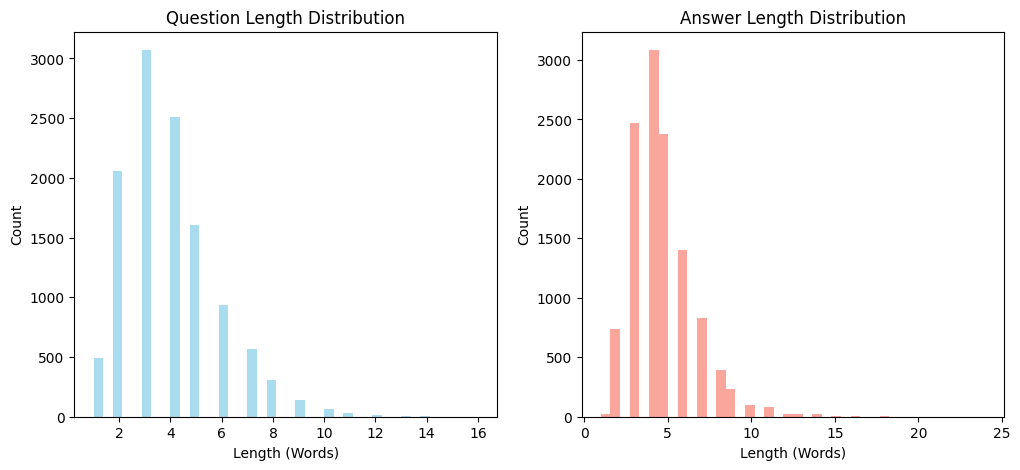

In [75]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 문장 길이(띄어쓰기 기준 단어 수) 계산
# (SentencePiece 토큰 수는 이보다 조금 더 많을 수 있지만, 비율은 비슷합니다)
q_len = [len(s.split()) for s in questions]
a_len = [len(s.split()) for s in answers]

# 2. 통계 정보 출력
print(f"질문 최대 길이: {np.max(q_len)}")
print(f"질문 평균 길이: {np.mean(q_len):.2f}")
print(f"질문 95% 지점: {np.percentile(q_len, 95)}") # 상위 95%가 이 길이 안에 들어옴
print("-" * 20)
print(f"답변 최대 길이: {np.max(a_len)}")
print(f"답변 평균 길이: {np.mean(a_len):.2f}")
print(f"답변 95% 지점: {np.percentile(a_len, 95)}")

# 3. 히스토그램 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(q_len, bins=40, color='skyblue', alpha=0.7, label='Question')
plt.title('Question Length Distribution')
plt.xlabel('Length (Words)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(a_len, bins=40, color='salmon', alpha=0.7, label='Answer')
plt.title('Answer Length Distribution')
plt.xlabel('Length (Words)')
plt.ylabel('Count')

plt.show()

In [78]:

MAX_LENGTH = 25
# ------------------------------------------
# 필터링 로직
# 질문과 답변 중 하나라도 MAX_LENGTH보다 길면 둘 다 버림.
# ------------------------------------------
new_questions = []
new_answers = []

for q, a in zip(questions, answers):
    # 띄어쓰기 기준 길이가 MAX_LENGTH 이하인 것만 남김
    if len(q.split()) <= MAX_LENGTH and len(a.split()) <= MAX_LENGTH:
        new_questions.append(q)
        new_answers.append(a)

# 덮어쓰기
questions = new_questions
answers = new_answers

print(f"기준 길이({MAX_LENGTH}) 이하로 필터링 완료!")
print(f"남은 데이터 개수: {len(questions)} (원래 개수에서 줄어들었는지 확인하세요)")

기준 길이(25) 이하로 필터링 완료!
남은 데이터 개수: 11823 (원래 개수에서 줄어들었는지 확인하세요)


In [82]:
import sentencepiece as spm
import os
import torch
from torch.nn.utils.rnn import pad_sequence

# ==========================================
# 1. 설정 및 하이퍼파라미터
# ==========================================
VOCAB_SIZE = 5000      # 단어장 크기
MAX_LENGTH = 25        # 문장 최대 길이
CORPUS_FILE = "corpus.txt"
MODEL_PREFIX = "chatbot_spm"

# ==========================================
# 2. 학습용 텍스트 파일 생성
# ==========================================
with open(CORPUS_FILE, 'w', encoding='utf-8') as f:
    for s in questions + answers:
        f.write(s + '\n')

print(f"학습 데이터 저장 완료: {CORPUS_FILE}")

# ==========================================
# 3. SentencePiece 모델 학습
# ==========================================
# pad_id=0, bos_id=1, eos_id=2, unk_id=3
spm.SentencePieceTrainer.Train(
    f'--input={CORPUS_FILE} '
    f'--model_prefix={MODEL_PREFIX} '
    f'--vocab_size={VOCAB_SIZE} '
    f'--model_type=bpe '
    f'--pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3 '
    f'--character_coverage=1.0 '
    f'--normalization_rule_name=identity'
)

# ==========================================
# 4. 모델 로드 및 특수 토큰 설정
# ==========================================
sp = spm.SentencePieceProcessor()
sp.Load(f'{MODEL_PREFIX}.model')

PAD_TOKEN = sp.pad_id()   # 0
START_TOKEN = sp.bos_id() # 1
END_TOKEN = sp.eos_id()   # 2

# ==========================================
# 5. 텍스트 -> 숫자 변환 (Tokenization & Padding)
# ==========================================
def tokenize_and_filter(inputs, outputs):
    tokenized_inputs, tokenized_outputs = [], []

    for (sentence1, sentence2) in zip(inputs, outputs):
        # 문장 -> 숫자 리스트 변환 (시작/종료 토큰 추가)
        sentence1 = [START_TOKEN] + sp.EncodeAsIds(sentence1) + [END_TOKEN]
        sentence2 = [START_TOKEN] + sp.EncodeAsIds(sentence2) + [END_TOKEN]

        # 최대 길이 이하인 문장만 남김
        if len(sentence1) <= MAX_LENGTH and len(sentence2) <= MAX_LENGTH:
            tokenized_inputs.append(sentence1)
            tokenized_outputs.append(sentence2)

    # 패딩(Padding) 추가하여 길이 맞추기
    input_tensor = [torch.LongTensor(s) for s in tokenized_inputs]
    output_tensor = [torch.LongTensor(s) for s in tokenized_outputs]

    input_padded = pad_sequence(input_tensor, batch_first=True, padding_value=PAD_TOKEN)
    output_padded = pad_sequence(output_tensor, batch_first=True, padding_value=PAD_TOKEN)

    return input_padded, output_padded

enc_train, dec_train = tokenize_and_filter(questions, answers)

print("-" * 30)
print(f"최종 학습 데이터 크기: {enc_train.shape}")
print(f"데이터 샘플(숫자): {enc_train[0]}")
print(f"데이터 샘플(복원): {sp.DecodeIds(enc_train[0].tolist())}")
print("-" * 30)

학습 데이터 저장 완료: corpus.txt
------------------------------
최종 학습 데이터 크기: torch.Size([11812, 25])
데이터 샘플(숫자): tensor([   1,  347, 4102, 3814, 3200,  108,    2,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0])
데이터 샘플(복원): 12시 땡 !
------------------------------


In [94]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import time
import numpy as np

# ==========================================
# 1. 모델 아키텍처
# ==========================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0
        self.depth = d_model // num_heads
        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)
        self.dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def forward(self, v, k, q, mask):
        batch_size = q.size(0)
        q = self.split_heads(self.wq(q), batch_size)
        k = self.split_heads(self.wk(k), batch_size)
        v = self.split_heads(self.wv(v), batch_size)
        scaled_attention_logits = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.depth)
        if mask is not None:
            scaled_attention_logits += (mask * -1e9)
        attention_weights = torch.nn.functional.softmax(scaled_attention_logits, dim=-1)
        output = torch.matmul(attention_weights, v)
        output = output.permute(0, 2, 1, 3).contiguous().view(batch_size, -1, self.d_model)
        return self.dense(output)

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dff, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = nn.Sequential(nn.Linear(d_model, dff), nn.ReLU(), nn.Linear(dff, d_model))
        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask):
        attn_output = self.dropout1(self.mha(x, x, x, mask))
        out1 = self.layernorm1(x + attn_output)
        ffn_output = self.dropout2(self.ffn(out1))
        out2 = self.layernorm2(out1 + ffn_output)
        return out2

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dff, dropout=0.1):
        super(DecoderLayer, self).__init__()
        self.mha1 = MultiHeadAttention(d_model, num_heads)
        self.mha2 = MultiHeadAttention(d_model, num_heads)
        self.ffn = nn.Sequential(nn.Linear(d_model, dff), nn.ReLU(), nn.Linear(dff, d_model))
        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)
        self.layernorm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_output, look_ahead_mask, padding_mask):
        attn1 = self.dropout1(self.mha1(x, x, x, look_ahead_mask))
        out1 = self.layernorm1(x + attn1)
        attn2 = self.dropout2(self.mha2(enc_output, enc_output, out1, padding_mask))
        out2 = self.layernorm2(out1 + attn2)
        ffn_output = self.dropout3(self.ffn(out2))
        out3 = self.layernorm3(out2 + ffn_output)
        return out3

class Transformer(nn.Module):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, target_vocab_size, pe_input, pe_target, dropout=0.1):
        super(Transformer, self).__init__()
        self.encoder_embedding = nn.Embedding(input_vocab_size, d_model)
        self.decoder_embedding = nn.Embedding(target_vocab_size, d_model)
        self.pos_encoding_input = PositionalEncoding(d_model, pe_input)
        self.pos_encoding_target = PositionalEncoding(d_model, pe_target)
        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, dff, dropout) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, dff, dropout) for _ in range(num_layers)])
        self.final_layer = nn.Linear(d_model, target_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, inp, tar, enc_padding_mask, look_ahead_mask, dec_padding_mask):
        enc_output = self.dropout(self.pos_encoding_input(self.encoder_embedding(inp) * math.sqrt(D_MODEL)))
        dec_output = self.dropout(self.pos_encoding_target(self.decoder_embedding(tar) * math.sqrt(D_MODEL)))

        for layer in self.encoder_layers:
            enc_output = layer(enc_output, enc_padding_mask)

        for layer in self.decoder_layers:
            dec_output = layer(dec_output, enc_output, look_ahead_mask, dec_padding_mask)

        return self.final_layer(dec_output)

# ==========================================
# 2. 마스킹 함수 및 설정
# ==========================================
def create_masks(inp, tar):
    enc_padding_mask = torch.eq(inp, 0).float()[:, np.newaxis, np.newaxis, :]
    dec_padding_mask = torch.eq(inp, 0).float()[:, np.newaxis, np.newaxis, :]
    look_ahead_mask = torch.triu(torch.ones(tar.size(1), tar.size(1)), diagonal=1).to(device)
    dec_target_padding_mask = torch.eq(tar, 0).float()[:, np.newaxis, np.newaxis, :]
    combined_mask = torch.max(look_ahead_mask, dec_target_padding_mask)
    return enc_padding_mask, combined_mask, dec_padding_mask

# 설정값
NUM_LAYERS = 6
D_MODEL = 256
NUM_HEADS = 8
UNITS = 1024
DROPOUT = 0.1
EPOCHS = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 3. 모델 생성 및 학습 시작
# ==========================================
model = Transformer(
    num_layers=NUM_LAYERS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dff=UNITS,
    input_vocab_size=VOCAB_SIZE,
    target_vocab_size=VOCAB_SIZE,
    pe_input=MAX_LENGTH,
    pe_target=MAX_LENGTH,
    dropout=DROPOUT
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=0.0001) # 간단한 LR 사용


for epoch in range(EPOCHS):
    start = time.time()
    total_loss = 0
    model.train()

    BATCH_SIZE = 64
    steps = len(enc_train) // BATCH_SIZE

    for step in range(steps):
        idx = step * BATCH_SIZE
        inp = enc_train[idx : idx + BATCH_SIZE].to(device)
        tar = dec_train[idx : idx + BATCH_SIZE].to(device)

        tar_inp = tar[:, :-1]
        tar_real = tar[:, 1:]

        enc_padding_mask, combined_mask, dec_padding_mask = create_masks(inp, tar_inp)

        optimizer.zero_grad()
        predictions = model(inp, tar_inp, enc_padding_mask, combined_mask, dec_padding_mask)
        loss = criterion(predictions.view(-1, VOCAB_SIZE), tar_real.contiguous().view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if step % 50 == 0:
            print(f'Epoch {epoch+1} Batch {step} Loss {loss.item():.4f}')

    print(f'Epoch {epoch+1} Loss {total_loss/steps:.4f} Time {time.time() - start:.2f}s')
    print("-" * 30)

print("Finish!")

Epoch 1 Batch 0 Loss 8.6776
Epoch 1 Batch 50 Loss 6.0752
Epoch 1 Batch 100 Loss 5.8626
Epoch 1 Batch 150 Loss 6.2067
Epoch 1 Loss 6.1567 Time 11.01s
------------------------------
Epoch 2 Batch 0 Loss 5.8595
Epoch 2 Batch 50 Loss 5.2579
Epoch 2 Batch 100 Loss 5.3840
Epoch 2 Batch 150 Loss 5.7916
Epoch 2 Loss 5.4936 Time 10.42s
------------------------------
Epoch 3 Batch 0 Loss 5.4793
Epoch 3 Batch 50 Loss 4.8769
Epoch 3 Batch 100 Loss 5.0802
Epoch 3 Batch 150 Loss 5.5710
Epoch 3 Loss 5.1856 Time 11.07s
------------------------------
Epoch 4 Batch 0 Loss 5.1502
Epoch 4 Batch 50 Loss 4.6059
Epoch 4 Batch 100 Loss 4.8545
Epoch 4 Batch 150 Loss 5.4008
Epoch 4 Loss 4.9387 Time 10.37s
------------------------------
Epoch 5 Batch 0 Loss 4.9073
Epoch 5 Batch 50 Loss 4.3784
Epoch 5 Batch 100 Loss 4.6577
Epoch 5 Batch 150 Loss 5.2030
Epoch 5 Loss 4.7189 Time 10.29s
------------------------------
Epoch 6 Batch 0 Loss 4.6648
Epoch 6 Batch 50 Loss 4.1882
Epoch 6 Batch 100 Loss 4.4538
Epoch 6 Batch

In [95]:
# ==========================================
# [테스트] 챗봇과 대화하기 (Inference)
# ==========================================
def predict(sentence):
    model.eval()

    # 1. 입력 문장 전처리
    try:
        sentence = preprocess_sentence(sentence)
    except NameError:
        pass # 전처리 함수 없으면 패스

    # 2. 토크나이징 (문장 -> 숫자)
    input_ids = [START_TOKEN] + sp.EncodeAsIds(sentence) + [END_TOKEN]
    enc_input = torch.LongTensor(input_ids).unsqueeze(0).to(device)

    # 3. 디코더 초기값 (START 토큰 하나로 시작)
    output_ids = [START_TOKEN]

    # 4. 답변 생성 루프
    for _ in range(MAX_LENGTH):
        dec_input = torch.LongTensor(output_ids).unsqueeze(0).to(device)

        # 마스크 생성
        enc_padding_mask, combined_mask, dec_padding_mask = create_masks(enc_input, dec_input)

        # 모델 예측
        with torch.no_grad():
            predictions = model(enc_input, dec_input, enc_padding_mask, combined_mask, dec_padding_mask)

        # 가장 확률 높은 다음 단어 선택
        predicted_id = torch.argmax(predictions[:, -1, :], dim=-1).item()

        # 종료 토큰이면 중단
        if predicted_id == END_TOKEN:
            break

        output_ids.append(predicted_id)

    # 5. 숫자 -> 문장 복원
    return sp.DecodeIds(output_ids[1:])

# ==========================================
# [실행] 대화 창 띄우기
# ==========================================
print("=" * 50)
print("챗봇이 준비되었습니다. (종료: q)")
print("=" * 50)

while True:
    try:
        user_input = input("나: ")

        if user_input.lower() in ['q', 'quit', 'exit']:
            print("대화를 종료합니다.")
            break

        response = predict(user_input)
        print(f"챗봇: {response}")
        print("-" * 30)

    except Exception as e:
        print(f"에러 발생: {e}")
        break

챗봇이 준비되었습니다. (종료: q)
나: 안녕
챗봇: 안녕하세요 .
------------------------------
나: 이름이 뭐야?
챗봇: 위로봇이요 .
------------------------------
나: 왜 위로봇이야?
챗봇: 당신은 따뜻한 물질방적하는 건 어떨까요 .
------------------------------
나: 내 이름 맞춰봐
챗봇: 확인해달라고 해보세요 .
------------------------------
나: 너 취미가 뭐야?
챗봇: 호감이 있을 수도 있어요 . 그렇지만 조금 더 상황을 지켜보세요 .
------------------------------
나: q
대화를 종료합니다.
